<center><h1>Фомин Иван Алексеевич</h1></center>

In [ ]:
!python -V # Версия Python

Python 3.12.13


In [ ]:
# Подавление предупреждений
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

# Импорт необходимых библиотек
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import polars as pl
import pandas as pd
import sklearn
import networkx as nx
# import jupyterlab as jlab
import ipywidgets
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D

## Домашнее задание: Обучение и визуализация трансформера

### Цель задания

1. Обучить простую модель трансформера для обработки любых данных (на выбор: текст, аудио, видео, изображения и ...)
2. Визуализировать веса внимания и интерпретировать их
3. Сделать выводы о том, как модель воспринимает данные и принимает решения

Используемое устройство: cuda


100%|██████████| 170M/170M [00:04<00:00, 37.3MB/s]


Начало обучения...
Эпоха [1/30] | Потери: 1.8716 | Точность (Train): 30.72% | Точность (Test): 43.00%
Эпоха [5/30] | Потери: 1.2366 | Точность (Train): 55.39% | Точность (Test): 57.85%
Эпоха [10/30] | Потери: 0.9739 | Точность (Train): 65.07% | Точность (Test): 65.77%
Эпоха [15/30] | Потери: 0.7931 | Точность (Train): 71.67% | Точность (Test): 70.54%
Эпоха [20/30] | Потери: 0.6462 | Точность (Train): 77.40% | Точность (Test): 73.93%
Эпоха [25/30] | Потери: 0.5391 | Точность (Train): 81.16% | Точность (Test): 75.13%
Эпоха [30/30] | Потери: 0.5022 | Точность (Train): 82.15% | Точность (Test): 75.44%


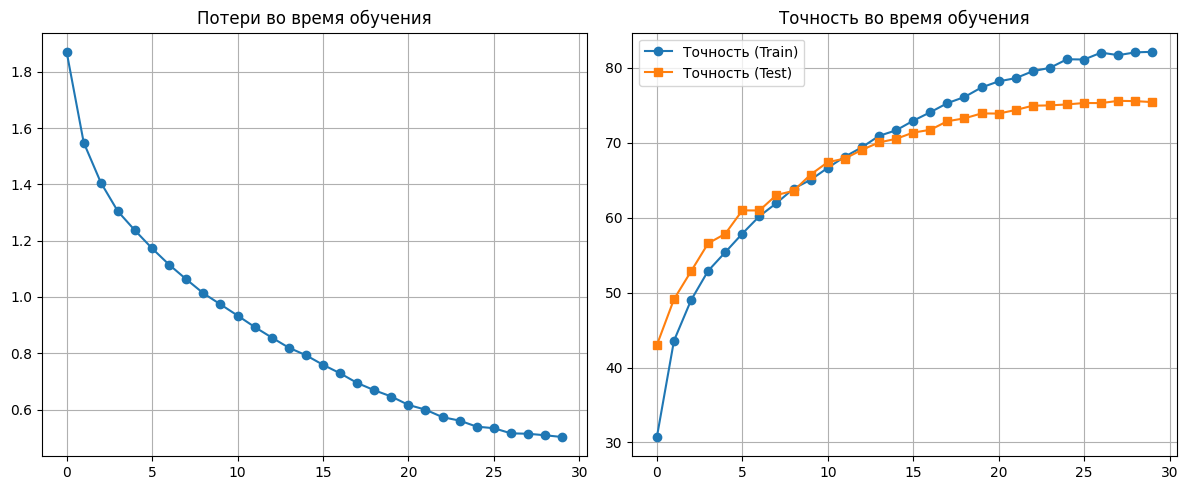


Генерация тепловых карт внимания...
Визуализация для: car


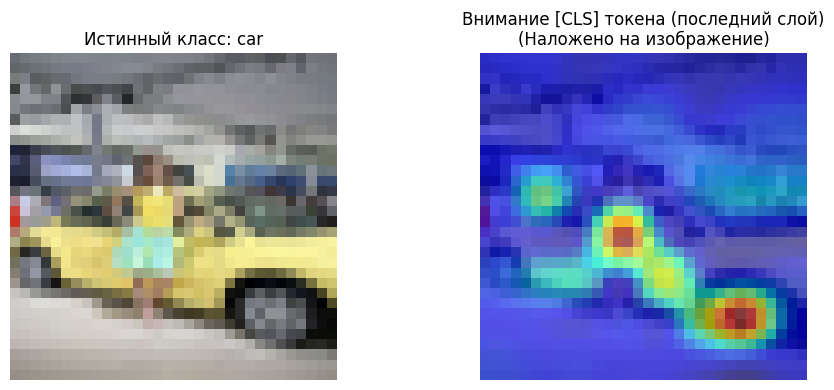

In [ ]:
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

def images_to_patches(x, patch_size=4):
    b, c, h, w = x.shape
    p = patch_size
    x = x.unfold(2, p, p).unfold(3, p, p)
    x = x.permute(0, 2, 3, 1, 4, 5).contiguous()
    x = x.view(b, (h//p)*(w//p), c * p * p)
    return x

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

class ImprovedVisionTransformer(nn.Module):
    def __init__(self, input_dim, num_classes, num_heads=8, num_layers=6, hidden_dim=256, dropout=0.1, seq_len=64):
        super(ImprovedVisionTransformer, self).__init__()

        self.embedding = nn.Linear(input_dim, hidden_dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, hidden_dim))
        self.positional_encoding = nn.Parameter(torch.randn(1, seq_len + 1, hidden_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads, dim_feedforward=hidden_dim * 2,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(hidden_dim, num_classes)
        self.attention_weights = []

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        x = self.embedding(x)

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.positional_encoding[:, :seq_len + 1, :]

        self.attention_weights = []

        for layer in self.transformer_encoder.layers:
            attn_out, attn_weights = layer.self_attn(x, x, x)
            self.attention_weights.append(attn_weights.detach())

            x = layer.norm1(x + attn_out)
            ffn_out = layer.linear2(layer.dropout(layer.activation(layer.linear1(x))))
            x = layer.norm2(x + ffn_out)

        cls_output = x[:, 0, :]
        return self.fc_out(cls_output)

input_dim = 48
seq_len = 64
num_classes = 10

model = ImprovedVisionTransformer(
    input_dim=input_dim, num_classes=num_classes, num_heads=8, num_layers=6, hidden_dim=256
).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

epochs = 30
train_losses, train_accs, test_accs = [], [], []

print("Начало обучения...")
for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        x_seq = images_to_patches(images, patch_size=4)

        optimizer.zero_grad()
        outputs = model(x_seq)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_losses.append(total_loss / len(train_loader))
    train_accs.append(100. * correct / total)

    model.eval()
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            x_seq = images_to_patches(images, patch_size=4)
            outputs = model(x_seq)
            _, predicted = outputs.max(1)
            total_test += labels.size(0)
            correct_test += predicted.eq(labels).sum().item()

    test_acc = 100. * correct_test / total_test
    test_accs.append(test_acc)

    if epoch == 0:
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scheduler.step()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Эпоха [{epoch+1}/{epochs}] | Потери: {train_losses[-1]:.4f} | Точность (Train): {train_accs[-1]:.2f}% | Точность (Test): {test_acc:.2f}%")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Потери (Train)', marker='o')
plt.title('Потери во время обучения')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Точность (Train)', marker='o')
plt.plot(test_accs, label='Точность (Test)', marker='s')
plt.title('Точность во время обучения')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

import torchvision.transforms.functional as TF

def plot_cls_attention_heatmap(model, image, label, class_names):
    model.eval()
    with torch.no_grad():
        img_tensor = image.unsqueeze(0).to(device)
        x_seq = images_to_patches(img_tensor, patch_size=4)

        _ = model(x_seq)

        attn_weights = model.attention_weights[-1].detach().cpu().numpy()

        if attn_weights.ndim == 4:
            cls_attention = attn_weights[0, :, 0, 1:].mean(axis=0)
        elif attn_weights.ndim == 3:
            if attn_weights.shape[0] == 1:
                cls_attention = attn_weights[0, 0, 1:]
            else:
                cls_attention = attn_weights[:, 0, 1:].mean(axis=0)
        elif attn_weights.ndim == 2:
            cls_attention = attn_weights[0, 1:]
        else:
            attn_weights = attn_weights.squeeze()
            if attn_weights.ndim == 2:
                cls_attention = attn_weights[0, 1:]
            elif attn_weights.ndim == 3:
                cls_attention = attn_weights[:, 0, 1:].mean(axis=0)

        attn_2d = cls_attention.reshape(8, 8)

        attn_tensor = torch.tensor(attn_2d).unsqueeze(0).unsqueeze(0)
        attn_upscaled = TF.resize(attn_tensor, [32, 32], interpolation=TF.InterpolationMode.BICUBIC)
        attn_upscaled = attn_upscaled.squeeze().numpy()

        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        img_np = image.permute(1, 2, 0).numpy()
        img_np = img_np * 0.5 + 0.5
        plt.imshow(img_np)
        plt.title(f"Истинный класс: {class_names[label]}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(img_np)
        plt.imshow(attn_upscaled, cmap='jet', alpha=0.6)
        plt.title("Внимание [CLS] токена (последний слой)\n(Наложено на изображение)")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

print("\nГенерация тепловых карт внимания...")
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

for _ in range(5):
    sample_idx = np.random.randint(0, len(test_dataset))
    sample_image, sample_label = test_dataset[sample_idx]

    if class_names[sample_label] in ['cat', 'dog', 'frog', 'car', 'ship', 'plane']:
        print(f"Визуализация для: {class_names[sample_label]}")
        plot_cls_attention_heatmap(model, sample_image, sample_label, class_names)
        break

Результаты модели лучше, чем у xLSTM (~69%) за то же время обучения, но всё ещё хуже, чем у простой свёрточной нейросети на 5 эпохе (77%), которая обучалась всего минуту... Однако в более сложных вариациях трансформеры могут показывать действительно хорошие результаты в том числе и для такой задачи.

Применение аугментации данных (RandomCrop, RandomHorizontalFlip) и планировщика скорости обучения (Cosine Annealing) оказалось критически важным. Это позволило преодолеть "плато" и достичь точности ~75%.

Визуализация весов самовнимания (Self-Attention) последнего слоя стала ключевым этапом анализа. Усреднение весов внимания от `[CLS]`-токена ко всем патчам изображения и наложение этой тепловой карты (heatmap) на оригинал наглядно продемонстрировало, что модель фокусируется на семантически значимых областях.

В отличие от CNN, трансформер не имеет встроенного предположения о локальности. Тот факт, что он всё равно научился выделять локальные объекты (части машины), говорит о высокой выразительной способности MHSA, который самостоятельно выстроил пространственные связи между патчами.
